In [341]:
# I start by import pandas and csv to read the file, which i name "file path". I then
# create the variables gross_area and total_site_energy_kbtu and assign them to their 
# respective columns in file_path.

import csv
import pandas as pd
file_path = 'boston_building_inventory_021020.csv'
with open(file_path, 'r') as file:
    csv_reader = csv.reader(file)
    for row in csv_reader:
        df=pd.read_csv(file_path)
        gross_area = df['gross_area']
        total_site_energy_kbtu = df['total_site_energy_kbtu']

In [342]:
# Now I create the variable site_EUI_variable and i print it sorted to start looking for outliers

site_EUI_variable = total_site_energy_kbtu//gross_area
#print(sorted(site_EUI_variable))

In [343]:
# i noticed that the most extreme outliers are 0.0 and inf.
# I create a boolean selector that i will use on site_EUI_variable and the other variables
# to remove the rows in which the outliers are. I will later add more components to 
# the boolean selector, so that i will remove any row associated to an outlier of any selected variable

bol_sel_EUI_1 = site_EUI_variable != 0.0
bol_sel_EUI_2 = site_EUI_variable != float('inf')
bol_sel_EUI_3 = bol_sel_EUI_1&bol_sel_EUI_2
#print(bol_sel_EUI_3)
#print(site_EUI_variable)

In [344]:
# Now i create variables that I believe can be predictor variables of site_EUI_variable
# I then print the variables sorted to look for outliers, and then I will eliminate the 
# rows associated to them by using boolean selectors. The potential predictor variables
# that I choose are year of building, percentage of low to no income, and percentage of 
# $200,000+ income.

year_built = df['yr_built']
#last_major_renovation = df['last_major_renovation_date']
perc_low_to_no_income = df['ct_perc_low_to_no_income']
perc_income_200000_or_more = df['ct_perc_income_200000_or_more']
#print(sorted(year_built))
bol_sel_yr_blt_1 = ~year_built.isna()
#print(sorted(bol_sel_yr_blt_1))
#print(sorted(perc_low_to_no_income))
bol_sel_low_income_1 = perc_low_to_no_income != 0
bol_sel_low_income_2 = ~perc_low_to_no_income.isna()
bol_sel_low_income_3 = bol_sel_low_income_1&bol_sel_low_income_2
#print(sorted(bol_sel_low_income_3))
bol_sel_200000_income_1 = perc_income_200000_or_more != 0
bol_sel_200000_income_2 = ~perc_income_200000_or_more.isna()
bol_sel_200000_income_3 = bol_sel_200000_income_1&bol_sel_200000_income_2
#print(sorted(bol_sel_200000_income_3))



In [345]:
# Now I combine all the boolean selectors (bol_sel) into one, and I apply it to the 
# variables I will compare 

bol_sel_tot = bol_sel_200000_income_3&bol_sel_EUI_3&bol_sel_low_income_3&bol_sel_yr_blt_1
#print(sorted(bol_sel_tot))
site_EUI_variable_cleaned = site_EUI_variable[bol_sel_tot]
#print(site_EUI_variable)
year_built_cleaned = year_built[bol_sel_tot]
perc_low_to_no_income_cleaned = perc_low_to_no_income[bol_sel_tot]
perc_income_200000_or_more_cleaned = perc_income_200000_or_more[bol_sel_tot]
#print(perc_low_to_no_income)

{'whiskers': [<matplotlib.lines.Line2D at 0x152eaf510>,
 'caps': [<matplotlib.lines.Line2D at 0x152f62150>,
 'boxes': [<matplotlib.lines.Line2D at 0x152eac890>],
 'medians': [<matplotlib.lines.Line2D at 0x152f60350>],
 'fliers': [<matplotlib.lines.Line2D at 0x153182190>],
 'means': []}

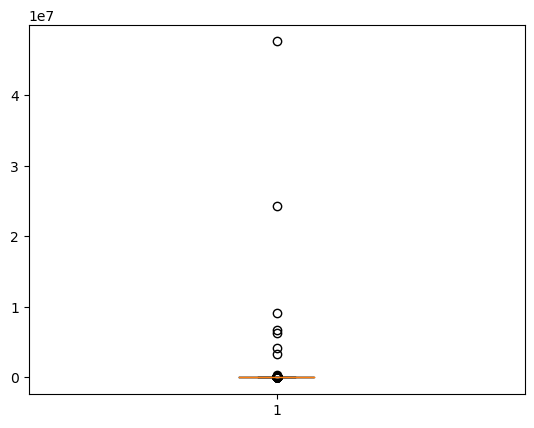

In [346]:
# To further clean the data, I look at the box plot of site_EUI_variable_cleaned. This
# will help me to spot less obvious outliers

import matplotlib.pyplot as plt
plt.boxplot(site_EUI_variable_cleaned)

In [347]:
# The box pot showed me that there are still a lot of outliers. Therefore, I use the IQR
# method to further clean the data. I create a boolean selector that I will use to clean
# the data in site_EUI_variable_cleaned and the other variables. 

import matplotlib.pyplot as plt

Q1 = site_EUI_variable_cleaned.quantile(0.30)
Q3 = site_EUI_variable_cleaned.quantile(0.70)
IQR = Q3-Q1
lower_bound_EUI = Q1-1.5*IQR
upper_bound_EUI = Q3+1.5*IQR
bol_sel_EUI_4 = (site_EUI_variable_cleaned < upper_bound_EUI) & (site_EUI_variable_cleaned > lower_bound_EUI) 
#print(sorted(bol_sel_EUI_4))
site_EUI_variable_2 = site_EUI_variable_cleaned[bol_sel_EUI_4]

#print(len(site_EUI_variable_2))
#print(len(site_EUI_variable_cleaned))

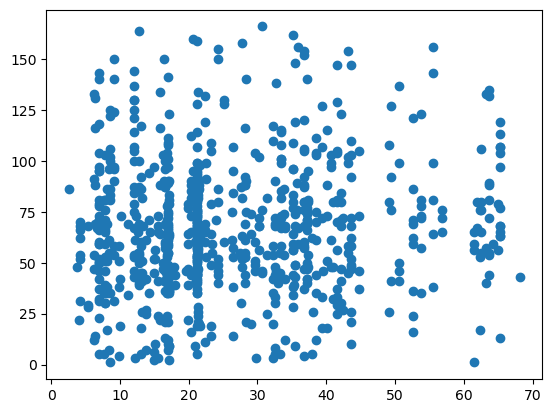

In [348]:
# I apply the boolean selector to the first potential predictor variable, and I run a 
# scatter plot between the latter and the EUI variable. Based on how good the scatter plot
# seems, I modify the values for Q1 and Q3 in the previous step.

perc_low_to_no_income_2 = perc_low_to_no_income_cleaned[bol_sel_EUI_4]
#print(sorted(perc_low_to_no_income_2))
#print(len(perc_low_to_no_income_2))
#print(len(perc_income_200000_or_more_cleaned))

plt.scatter(perc_low_to_no_income_2, site_EUI_variable_2)

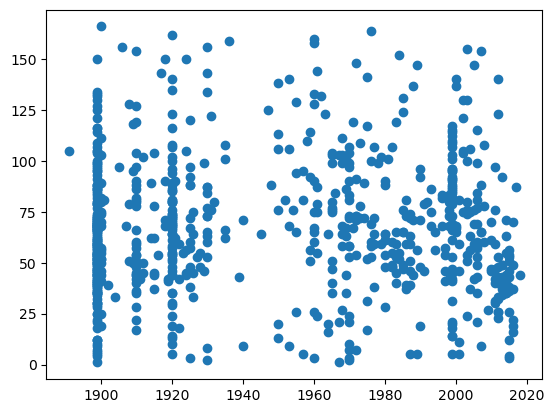

In [349]:
# Then I do the same thing with the building year variable...
year_built_2 = year_built_cleaned[bol_sel_EUI_4]
#print(len(year_built_2))

plt.scatter(year_built_2, site_EUI_variable_2)

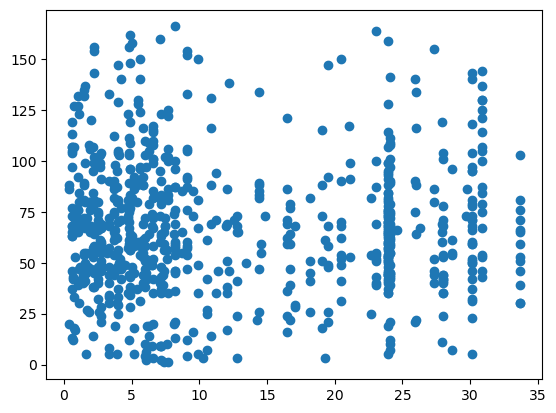

In [350]:
# ...and with the percentage of $200,000+ salary variable 

perc_income_200000_or_more_2 = perc_income_200000_or_more_cleaned[bol_sel_EUI_4]
#print(len(year_built_2))

plt.scatter(perc_income_200000_or_more_2, site_EUI_variable_2)

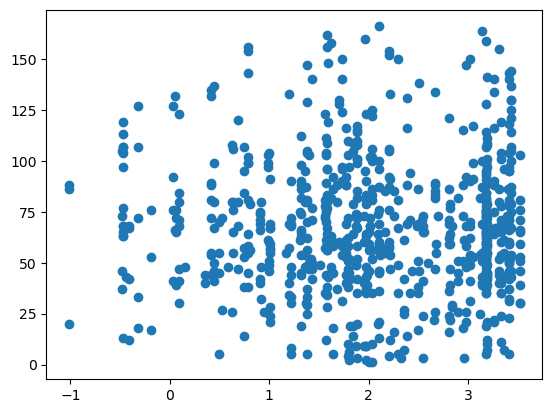

In [351]:
# The variables perc_low_to_no_income_2 and perc_income_2000_or_more_2 seem to have a 
# greater correlation to the EUI than the year of building variable. Howeverer, their 
# correlation does not seem very strong. To try to better the correlation, I try the
# same process of the last step using the logarythm of the the two income variables.

import math
import numpy as np
perc_income_200000_or_more_log = perc_income_200000_or_more_2.apply(np.log)
plt.scatter(perc_income_200000_or_more_log, site_EUI_variable_2)

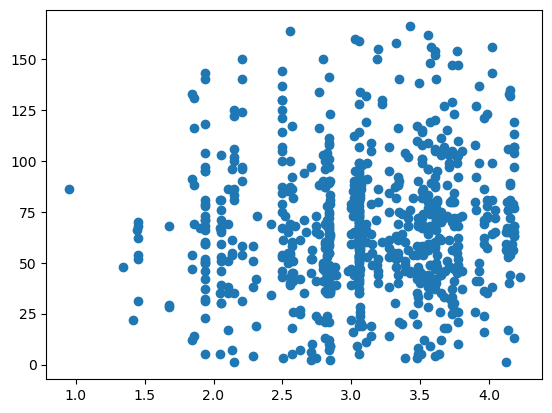

In [352]:
perc_low_to_no_income_log = perc_low_to_no_income_2.apply(np.log)
plt.scatter(perc_low_to_no_income_log, site_EUI_variable_2)

In [353]:
# The logarythm of the two income variables seem to have a stronger correlation with the
# EUI. I will now run a regression model between each income variable and their
# logarythm and the EUI, to confirm if the logarythm variables are actually a better predictant.

In [354]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [355]:
import statsmodels.api as sm
X = perc_low_to_no_income_2
Y = site_EUI_variable_2
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
model.summary()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     6.084
Date:                Thu, 08 Feb 2024   Prob (F-statistic):             0.0139
Time:                        21:48:31   Log-Likelihood:                -3676.3
No. Observations:                 750   AIC:                             7357.
Df Residuals:                     748   BIC:                             7366.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       62.0391      2.379     26.082      0.000      57.370      66.709
ct_perc_low_to_no_income     0.1909      0.077      2.467      0.014       0.039       0.343
==============================================================================
Omnibus:                       30.798   Durbin-Watson:                   1.817
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               33.492
Skew:                           0.503   Prob(JB):                     5.34e-08
Kurtosis:                       3.240   Cond. No.                         61.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [356]:
X = perc_low_to_no_income_log
Y = site_EUI_variable_2
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
model.summary()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     4.577
Date:                Thu, 08 Feb 2024   Prob (F-statistic):             0.0327
Time:                        21:48:31   Log-Likelihood:                -3677.1
No. Observations:                 750   AIC:                             7358.
Df Residuals:                     748   BIC:                             7367.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       54.6998      5.926      9.230      0.000      43.066      66.334
ct_perc_low_to_no_income     4.0079      1.873      2.139      0.033       0.330       7.686
==============================================================================
Omnibus:                       30.520   Durbin-Watson:                   1.817
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               33.156
Skew:                           0.502   Prob(JB):                     6.31e-08
Kurtosis:                       3.230   Cond. No.                         17.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [357]:
X = perc_income_200000_or_more_2
Y = site_EUI_variable_2
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
model.summary()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                  0.008969
Date:                Thu, 08 Feb 2024   Prob (F-statistic):              0.925
Time:                        21:48:31   Log-Likelihood:                -3679.4
No. Observations:                 750   AIC:                             7363.
Df Residuals:                     748   BIC:                             7372.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            67.2585      1.899     35.413      0.000      63.530      70.987
ct_perc_income_200000_or_more    -0.0110      0.117     -0.095      0.925      -0.240       0.218
==============================================================================
Omnibus:                       30.113   Durbin-Watson:                   1.830
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               32.663
Skew:                           0.498   Prob(JB):                     8.08e-08
Kurtosis:                       3.229   Cond. No.                         26.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [358]:
X = perc_income_200000_or_more_log
Y = site_EUI_variable_2
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
model.summary()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.4872
Date:                Thu, 08 Feb 2024   Prob (F-statistic):              0.485
Time:                        21:48:31   Log-Likelihood:                -3679.1
No. Observations:                 750   AIC:                             7362.
Df Residuals:                     748   BIC:                             7371.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            68.7127      2.577     26.660      0.000      63.653      73.772
ct_perc_income_200000_or_more    -0.7674      1.099     -0.698      0.485      -2.926       1.391
==============================================================================
Omnibus:                       30.105   Durbin-Watson:                   1.827
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               32.653
Skew:                           0.497   Prob(JB):                     8.12e-08
Kurtosis:                       3.237   Cond. No.                         5.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [359]:
# Out of the 4 variables tested through a regression model - low income, its logarythm, high
# income and its logarythm - the low income variable seems to be the best predictant of the
# EUI variable. The regression model between the low income and the EUI variables showed
# the highest value for R^2, which means that the variance of EUI is best explained by 
# the low income variable out of the 4 variables tested. 0.008 is a low value
# for R^2 - which means that it is not a great fit. However, the low P(F-statistic) value indicates
# that the F-statistic is significant. Same thing for the t-value and its probability. 
# Overall, the model is statistically significant. 